In [1]:
import pandas as pd
url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"
df = pd.read_csv(url)
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [6]:
df["Age"] = df["Age"].fillna(df["Age"].median())
df["Embarked"] = df["Embarked"].fillna(df["Embarked"].mode()[0])
df = df.drop(["Cabin","Name","Ticket","PassengerId"], axis=1)
df = pd.get_dummies(df, columns=["Sex","Embarked"], drop_first=True)
df.isnull().sum()

,0
Survived,0
Pclass,0
Age,0
SibSp,0
Parch,0
Fare,0
Sex_male,0
Embarked_Q,0
Embarked_S,0


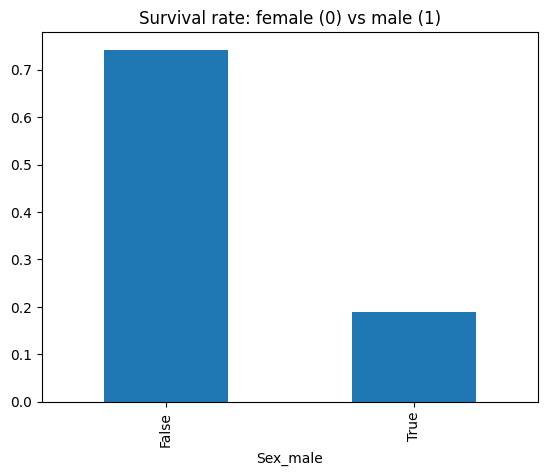

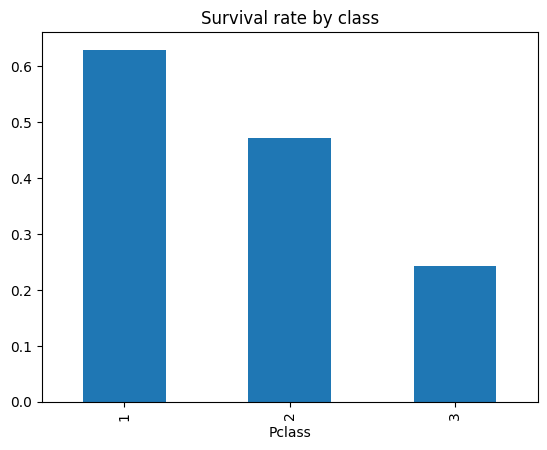

In [7]:
import matplotlib.pyplot as plt
df.groupby("Sex_male")["Survived"].mean().plot(kind="bar", title="Survival rate: female (0) vs male (1)")
plt.show()
df.groupby("Pclass")["Survived"].mean().plot(kind="bar", title="Survival rate by class")
plt.show()

In [8]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

X = df.drop("Survived", axis=1)
y = df["Survived"]
Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=0.2, random_state=42)
m = RandomForestClassifier(random_state=42).fit(Xtr, ytr)
print("Accuracy:", accuracy_score(yte, m.predict(Xte)))
print(pd.Series(m.feature_importances_, index=X.columns).sort_values(ascending=False).head(3))

Accuracy: 0.8212290502793296
Sex_male    0.273316
Fare        0.272058
Age         0.252745
dtype: float64
